# Honours Research Part 1: Preliminary Research/Coding
## Objective:
Replicating "A novel epileptic seizure prediction method based on synchroextracting transform and 1-dimensional convolutional neural network" by Ra et al. (2023).

### Load EEG files and montages

Extracting EDF parameters from chb02/chb02_01.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from chb02/chb02_16+.edf...
Setting channel info structure...
Creating raw.info structure...
<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2074-07-24 15:29:39 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


C:\Users\Mary Yap\AppData\Local\Temp\ipykernel_43564\2023185947.py:4: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf("chb02/chb02_01.edf")
C:\Users\Mary Yap\AppData\Local\Temp\ipykernel_43564\2023185947.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  pre_ictal = mne.io.read_raw_edf("chb02/chb02_16+.edf")


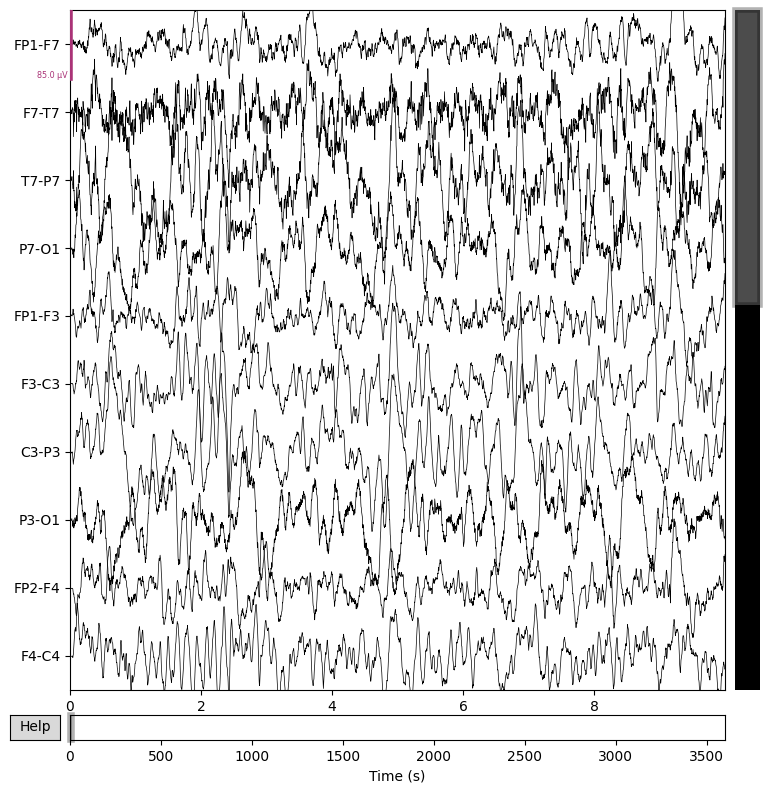

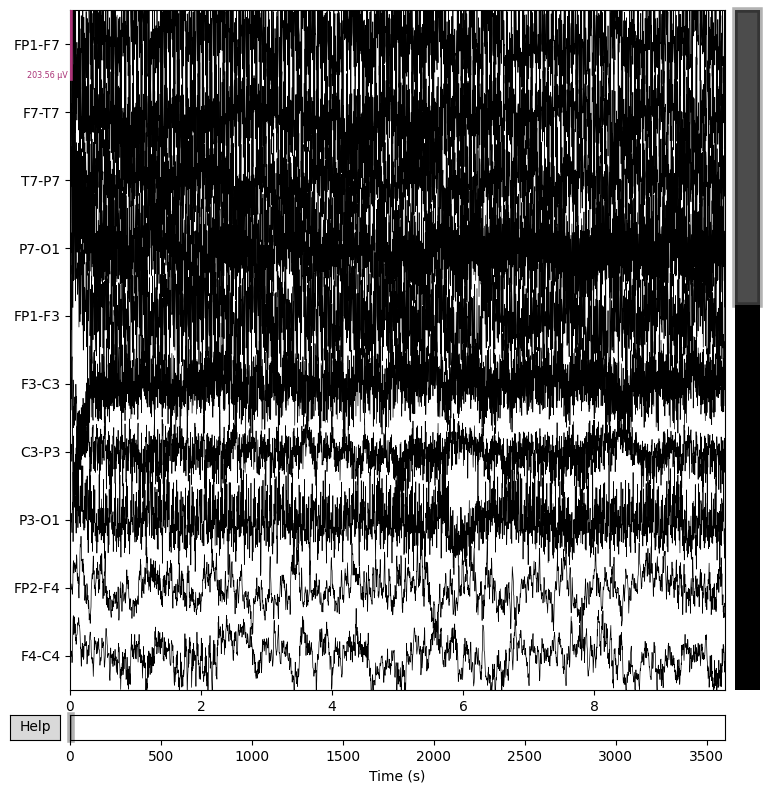

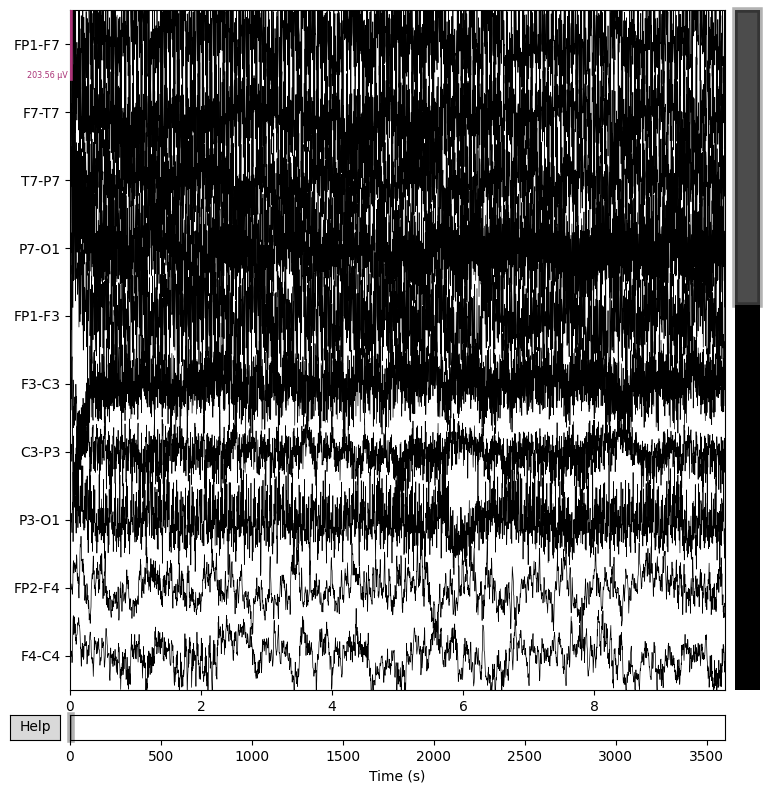

In [11]:
import mne

# Load files from CHB-MIT Database
raw = mne.io.read_raw_edf("chb02/chb02_01.edf")
pre_ictal = mne.io.read_raw_edf("chb02/chb02_16+.edf")

# Print metadata
print(raw.info)

# Print channel names
print(raw.ch_names)

# Plot graphs
raw.plot(duration=10, n_channels=10, scalings='auto')
pre_ictal.plot(duration=10, n_channels=10, scalings='auto')

### Extract 2.8 second clips from normal and pre-ictal periods (10:1 ratio)

In [12]:
import numpy as np
import random

# Configure frequency, window duration, etc.
sampling_rate = 256
duration = 2.8 # seconds
clip_length = int(sampling_rate * duration) # 716 samples
total_seconds_in_hour = 3600 

normal_clips_list = []

# Extract 10 normal clips
for _ in range(10):
    # Pick a random second between 0 and 3590
    start_sec = random.randint(0, total_seconds_in_hour - 10)
    
    start_sample = int(start_sec * sampling_rate)
    stop_sample = start_sample + clip_length
    
    # Grab the data for ALL channels (or just channel 0)
    chunk = raw.get_data(start=start_sample, stop=stop_sample)
    normal_clips_list.append(chunk)

# Convert list to 3D numpy array: (Number of clips, Channels, Samples)
X_normal = np.array(normal_clips_list)

print(f"Normal clip array shape: {X_normal.shape}") # Check

# Define seizure window
seizure_start = 2972
sph = seizure_start - 600  # 2372

# Convert to samples from seconds
start_pre_ictal = int(sph * sampling_rate)
stop_pre_ictal = start_pre_ictal + clip_length

# Extract pre-ictal clip
pre_ictal_data = pre_ictal.get_data()
pre_ictal_clip = pre_ictal_data[0, start_pre_ictal:stop_pre_ictal]

print(f"Pre-ictal clip shape: {pre_ictal_clip.shape}") # Check

Normal clip array shape: (10, 23, 716)
Pre-ictal clip shape: (716,)


### Create overlapping windows

In [13]:
# Create overlapping windows of length=10, step=5
def moving_window(data, window_size, step_size):
    num_points = len(data)
    window_length = window_size # Length of window in samples
    step_length = step_size # Length of step in samples
    windows = []
    for start in range(0, num_points - window_length + 1, step_length):
        windows.append(data[start:start + window_length])
    return np.array(windows)

window_size = 10 # Length of window (samples)
step_size = 5 # Length of step (samples)

# Create overlapping windows for all 10 normal clips
normal_windows = {}
for i in range(10):
    windows = moving_window(X_normal[i, 0, :], window_size, step_size)
    normal_windows[f"clip_{i}"] = windows

# Create overlapping windows for pre-ictal clip
pre_ictal_windows = moving_window(pre_ictal_clip, window_size, step_size)

print(normal_windows["clip_2"]) # Check
print(pre_ictal_windows) # Check

[[ 4.86446886e-05  3.32112332e-06  2.05128205e-05 ... -3.77045177e-05
  -3.22344322e-05  2.12942613e-05]
 [-1.77777778e-05 -5.27472527e-06 -3.77045177e-05 ...  4.70818071e-05
   4.59096459e-05  3.53601954e-05]
 [ 4.10256410e-06  2.79365079e-05  4.70818071e-05 ... -3.26251526e-05
  -2.53968254e-06  4.43467643e-05]
 ...
 [ 1.95360195e-07  1.42612943e-05  2.09035409e-05 ... -1.77777778e-05
  -4.43467643e-05 -1.54334554e-05]
 [ 2.71550672e-05  2.01221001e-05 -1.77777778e-05 ... -9.57264957e-06
  -3.30158730e-05 -5.84126984e-05]
 [-9.18192918e-06 -7.22832723e-06 -9.57264957e-06 ...  3.32112332e-06
   2.48107448e-05 -1.58241758e-05]]
[[-1.07448107e-05  1.03345543e-04  1.58241758e-05 ...  2.13919414e-04
   3.69230769e-05 -1.13894994e-04]
 [-9.39682540e-05 -4.66910867e-05  2.13919414e-04 ...  3.80952381e-05
  -2.93040293e-06  2.27203907e-04]
 [ 1.82661783e-04  3.14334554e-04  3.80952381e-05 ...  4.00488400e-05
   7.91208791e-05  1.42612943e-05]
 ...
 [-8.00976801e-06 -1.85787546e-04  1.3479853

### Stack all windows

In [14]:
# Combine all normal windows into one array
all_normal = np.vstack(list(normal_windows.values()))

# Combine normal + pre-ictal
X_windows = np.vstack([all_normal, pre_ictal_windows])

# Create labels: normal=0, pre-ictal=1
y_labels = np.hstack([
    np.zeros(len(all_normal)),
    np.ones(len(pre_ictal_windows))
])

print("X_windows shape:", X_windows.shape)
print("y_labels shape:", y_labels.shape)

X_windows shape: (1562, 10)
y_labels shape: (1562,)


### Feature extract STFT

In [15]:
from scipy.signal import stft
import numpy as np

def compute_stft(window, nperseg=10):
    f, t, Zxx = stft(window, nperseg=nperseg)
    return np.abs(Zxx)

stft_features = []

for w in X_windows:
    tfr = compute_stft(w)
    stft_features.append(tfr)

stft_features = np.array(stft_features)

print("STFT shape:", stft_features.shape)


STFT shape: (1562, 6, 3)


### Feature extract SET-SVD

In [16]:
def compute_set(signal, fs):

    N = len(signal)

    f, t, Zxx = stft(signal, fs=fs, nperseg=N//4)

    eps = 1e-8
    Zxx = np.where(np.abs(Zxx) < eps, eps, Zxx)

    phase = np.unwrap(np.angle(Zxx), axis=1)

    dphi_dt = np.diff(phase, axis=1)
    dphi_dt = np.hstack([dphi_dt, dphi_dt[:, -1][:, None]])

    dt = t[1] - t[0]

    IF = dphi_dt / (2*np.pi*dt)

    reassigned = np.zeros_like(Zxx)

    for fi in range(len(f)):
        for ti in range(len(t)):

            target_f = IF[fi, ti]

            idx = np.argmin(np.abs(f - target_f))

            reassigned[idx, ti] += np.abs(Zxx[fi, ti])

    return reassigned

def compute_set_svd(signal, fs, k=10):

    TFR = compute_set(signal, fs)

    U, S, Vt = np.linalg.svd(TFR, full_matrices=False)

    return S[:k]

In [17]:
'''
set_svd_features = []
set_singular_values = []

for clip in all_clips:
    reduced, svals = compute_set_svd(clip, k=10)
    set_svd_features.append(reduced)
    set_singular_values.append(svals)

set_svd_features = np.array(set_svd_features)
set_singular_values = np.array(set_singular_values)

print("SET-SVD feature shape:", set_svd_features.shape)
print("Singular value vectors shape:", set_singular_values.shape)
'''

'\nset_svd_features = []\nset_singular_values = []\n\nfor clip in all_clips:\n    reduced, svals = compute_set_svd(clip, k=10)\n    set_svd_features.append(reduced)\n    set_singular_values.append(svals)\n\nset_svd_features = np.array(set_svd_features)\nset_singular_values = np.array(set_singular_values)\n\nprint("SET-SVD feature shape:", set_svd_features.shape)\nprint("Singular value vectors shape:", set_singular_values.shape)\n'

In [18]:
X = stft_features.reshape(stft_features.shape[0], -1)

print("Flattened shape:", X.shape)
# Expected: (1562, 18)

Flattened shape: (1562, 18)


### Train and test MLP model using STFT

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels,
    test_size=0.2,
    random_state=42,
    stratify=y_labels  # use if classification
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

mlp.fit(X_train, y_train)

print("Train accuracy:", mlp.score(X_train, y_train))
print("Test accuracy:", mlp.score(X_test, y_test))

y_pred = mlp.predict(X_test)

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

Train accuracy: 0.9799839871897518
Test accuracy: 0.987220447284345
[[283   2]
 [  2  26]]
              precision    recall  f1-score   support

         0.0     0.9930    0.9930    0.9930       285
         1.0     0.9286    0.9286    0.9286        28

    accuracy                         0.9872       313
   macro avg     0.9608    0.9608    0.9608       313
weighted avg     0.9872    0.9872    0.9872       313



### Train and test 1-d CNN model using STFT

In [22]:
y = y_labels.astype(np.int64)

# pick ONE:
USE_CONV_OVER_FREQ = True

if USE_CONV_OVER_FREQ:
    X_cnn = np.transpose(stft_features, (0, 2, 1))  # (N, C=T, L=F)
else:
    X_cnn = stft_features                            # (N, C=F, L=T)

N, C, L = X_cnn.shape

# scale across features
scaler = StandardScaler()
X_flat = X_cnn.reshape(N, -1)
X_flat = scaler.fit_transform(X_flat)
X_cnn = X_flat.reshape(N, C, L).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y, test_size=0.2, random_state=42, stratify=y
)

print("CNN input train shape:", X_train.shape)  # (N_train, C, L)

import torch
import torch.nn as nn
import torch.nn.functional as F

class STFT1DCNN(nn.Module):
    def __init__(self, in_channels, n_classes=2):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(64)
        self.drop = nn.Dropout(0.3)
        self.fc = nn.Linear(64, n_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = x.mean(dim=2)          # global average pooling over L
        x = self.drop(x)
        return self.fc(x)          # logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = STFT1DCNN(in_channels=C).to(device)

import numpy as np

X_train_t = torch.tensor(X_train).to(device)
y_train_t = torch.tensor(y_train).to(device)
X_test_t  = torch.tensor(X_test).to(device)
y_test_t  = torch.tensor(y_test).to(device)

# class weights for imbalance
counts = np.bincount(y_train)
w0 = 1.0 / counts[0]
w1 = 1.0 / counts[1]
class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(device)

loss_fn = nn.CrossEntropyLoss(weight=class_weights)
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(1, 201):
    model.train()
    opt.zero_grad()
    logits = model(X_train_t)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    opt.step()

    if epoch % 20 == 0:
        model.eval()
        with torch.no_grad():
            pred = model(X_test_t).argmax(dim=1)
            acc = (pred == y_test_t).float().mean().item()
        print(f"Epoch {epoch:03d} | loss {loss.item():.4f} | test acc {acc:.4f}")

from sklearn.metrics import confusion_matrix, classification_report

model.eval()
with torch.no_grad():
    y_pred = model(X_test_t).argmax(dim=1).cpu().numpy()

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

CNN input train shape: (1249, 3, 6)
Epoch 020 | loss 0.3550 | test acc 0.8786
Epoch 040 | loss 0.2302 | test acc 0.9457
Epoch 060 | loss 0.1582 | test acc 0.9553
Epoch 080 | loss 0.1138 | test acc 0.9617
Epoch 100 | loss 0.0877 | test acc 0.9681
Epoch 120 | loss 0.0719 | test acc 0.9712
Epoch 140 | loss 0.0552 | test acc 0.9744
Epoch 160 | loss 0.0446 | test acc 0.9744
Epoch 180 | loss 0.0381 | test acc 0.9744
Epoch 200 | loss 0.0334 | test acc 0.9776
[[278   7]
 [  0  28]]
              precision    recall  f1-score   support

           0     1.0000    0.9754    0.9876       285
           1     0.8000    1.0000    0.8889        28

    accuracy                         0.9776       313
   macro avg     0.9000    0.9877    0.9382       313
weighted avg     0.9821    0.9776    0.9787       313



### Results for STFT (MLP vs 1-d CNN)

**When using chb_19 pre-ictal data (only 9 second seizure):**

STFT MLP: Only predicted 1 pre-ictal case out of 28, with technically perfect precision. Thus model is extremely conservative with predicting pre-ictal and leads to many false negatives.

STFT 1-d CNN: Lower accuracy but better sensitivity to the minority class as recall = 0.286. Correctly identified more pre-ictal samples but increased false alarm rate, hence low precision.
| Model        | Precision (Pre-ictal) |Recall (Pre-ictal)| Accuracy |
|--------------|----------------------|-------------------|----------|
| STFT + MLP   | 1.0000               | 0.0357            | 0.9137   |
| STFT + CNN   | 0.0899               | 0.2857            | 0.6773   |


**When using chb_16+ pre-ictal data (81 second seizure):**
| Model        | Precision (Pre-ictal) | Recall (Pre-ictal) | Accuracy |
|--------------|----------------------|-------------------|----------|
| STFT + MLP   | 0.9286               | 0.9286            | 0.9872   |
| STFT + CNN   | 0.8000               | 1.0000            | 0.9776   |

MLP was more precise at the risk of more false negatives, whereas CNN was less precise but caught all true seizures (perfect recall). Both models had better-than-random accuracy (normal to pre-ictal 9.8:1).

**Original paper by Ra et al.:**
| Model        | Precision (Pre-ictal) | Recall (Pre-ictal) | Accuracy |
|--------------|----------------------|-------------------|----------|
| STFT + MLP   | 0.7709               | 0.9444            | 0.8973   |
| STFT + CNN   | 0.8565               | 0.9351            | 0.9159   |
